# Midterm: Export Strategy
## Anthony Costanzo
## Friday, March 6th

## Executive Summary

South Korea's Ministry of Commerce should target new export funds toward three priorities: deepening its regional trade agreement network, investing in the precision materials and specialty chemicals ecosystems where Korea holds its strongest comparative advantages, and reducing logistics costs that remain the single largest structural barrier to export growth. These recommendations follow directly from a comprehensive analysis of Korea's economic performance, export structure, and trade costs.

Development accounting shows that Korea's growth since 1980 has been driven almost entirely by capital accumulation, with TFP remaining flat — meaning future productivity gains require structural transformation rather than continued factor investment. RCA analysis reveals that Korea's deepest specialization lies in Photographic/Cinematographic Goods (HS 37) and Inorganic Chemicals (HS 28), while legacy labor-intensive sectors including Silk (HS 50) and Raw Hides (HS 41) are in sustained decline. A gravity model of Korea's 2020 bilateral trade flows confirms that Regional Trade Agreements are the most policy-responsive lever available, associated with roughly 68% higher exports to partner countries, while WTO membership among destination partners shows no statistically significant effect — suggesting Korea's export strategy must increasingly rely on bilateral and regional institutional arrangements rather than multilateral frameworks.

## Problem 3: Economic Performance (Background)

In [1]:
# Import Packages and Load Data
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
# Loading Data
pwt = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-pwt.csv")

In [3]:
# Set capital share parameter: A = Y / K^0.33 * (hL)^0.67
alpha = 0.33

def add_series(df, start_year=1980):
    df = df[df["year"] >= start_year].copy()             
    df["y"] = df["rgdpo"] / df["pop"]                    # output per capita (Y/L)
    df["k"] = df["cn"] / df["pop"]                       # capital per capita (K/L)
    df["A"] = df["y"] / (df["k"] ** alpha * df["hc"] ** (1 - alpha))  # TFP residual from production function
    df["lny"] = np.log(df["y"])                          # log output per capita
    df["lnk"] = np.log(df["k"])                          # log capital per capita
    df["lnA"] = np.log(df["A"])                          # log TFP
    return df

In [4]:
# Filter to South Korea and Taiwan and compute time series
pwt_kr = add_series(pwt[pwt["countrycode"] == "KOR"])    # primary country — subset to Korea rows and run add_series
pwt_tw = add_series(pwt[pwt["countrycode"] == "TWN"])    # comparator — same as above but for Taiwan


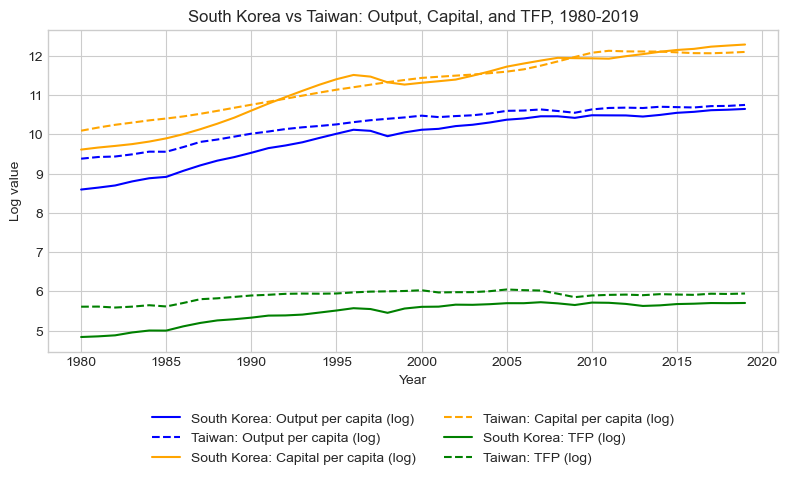

In [5]:
# Variable names, legend labels, and colors
variables = {"lny": "Output per capita (log)", "lnk": "Capital per capita (log)", "lnA": "TFP (log)"} 
colors    = {"lny": "blue", "lnk": "orange", "lnA": "green"}

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8, 5))

# Plot each variable for both countries — South Korea solid, Taiwan dashed
for var, label in variables.items():
    plt.plot(pwt_kr["year"], pwt_kr[var], color=colors[var], label=f"South Korea: {label}")
    plt.plot(pwt_tw["year"], pwt_tw[var], color=colors[var], linestyle="--", label=f"Taiwan: {label}")

plt.xlabel("Year")
plt.ylabel("Log value")
plt.title("South Korea vs Taiwan: Output, Capital, and TFP, 1980-2019")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

South Korea's strong economic growth from 1980 to 2019 was driven primarily by capital accumulation rather than productivity gains, suggesting that future growth will require a shift toward policies that boost TFP. Over the four-decade period, Korea's capital per capita grew substantially, rising from roughly 10 to over 12 log points, while total factor productivity remained nearly flat throughout — a pattern that persisted even after Korea democratized in 1987, suggesting that political liberalization alone was insufficient to shift the economy toward TFP-driven growth. Taiwan's trajectory tells a similar story: despite undergoing its own democratic transition the same year, Taiwan's TFP also stagnated, though its comparatively slower capital deepening meant Korea was able to close the output-per-capita gap with Taiwan entirely by 2019. Together, both economies appear to have exhausted the easy gains from adding capital and labor — consistent with Krugman's argument about capital accumulation driving Soviet-style growth — pointing to the need for policies that directly target allocative efficiency, R&D, and innovation.

## Problem 4a: Export and Comparative Advantage Assessment

In [6]:
# Load industry flows and filter to South Korea, years 2000 and 2022
industryflows = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-industryflows.csv")
kor = industryflows[(industryflows["iso_o"] == "KOR") & (industryflows["year"].isin([2000, 2021]))].copy()

In [7]:
# Compute RCA for each year independently, then stack
frames = []
for year, group in kor.groupby("year"):
    group = group[group["value"] > 0].copy()               # drop sectors Korea doesn't export
    group["value_tot"]    = group["value"].sum()            # total Korean exports that year
    group["value_wd_tot"] = group["value_wd"].sum()         # total world exports that year
    group["sh_hs2"]       = group["value"] / group["value_wd"]          # Korea's sector share of world exports
    group["sh_wd"]        = group["value_tot"] / group["value_wd_tot"]  # Korea's overall world export share
    group["rca"]          = group["sh_hs2"] / group["sh_wd"]            # Balassa RCA index
    frames.append(group)
kor = pd.concat(frames)

# Pivot to get 2000 and 2021 RCA side by side, then compute change
rca = kor.pivot(index="hs2", columns="year", values="rca").reset_index()
rca.columns.name = None                                                  # clear column axis name
rca = rca.rename(columns={2000: "rca_2000", 2021: "rca_2021"})          # rename by value, not position
rca["rca_change"] = rca["rca_2021"] - rca["rca_2000"]                   # change in RCA 2000-2021

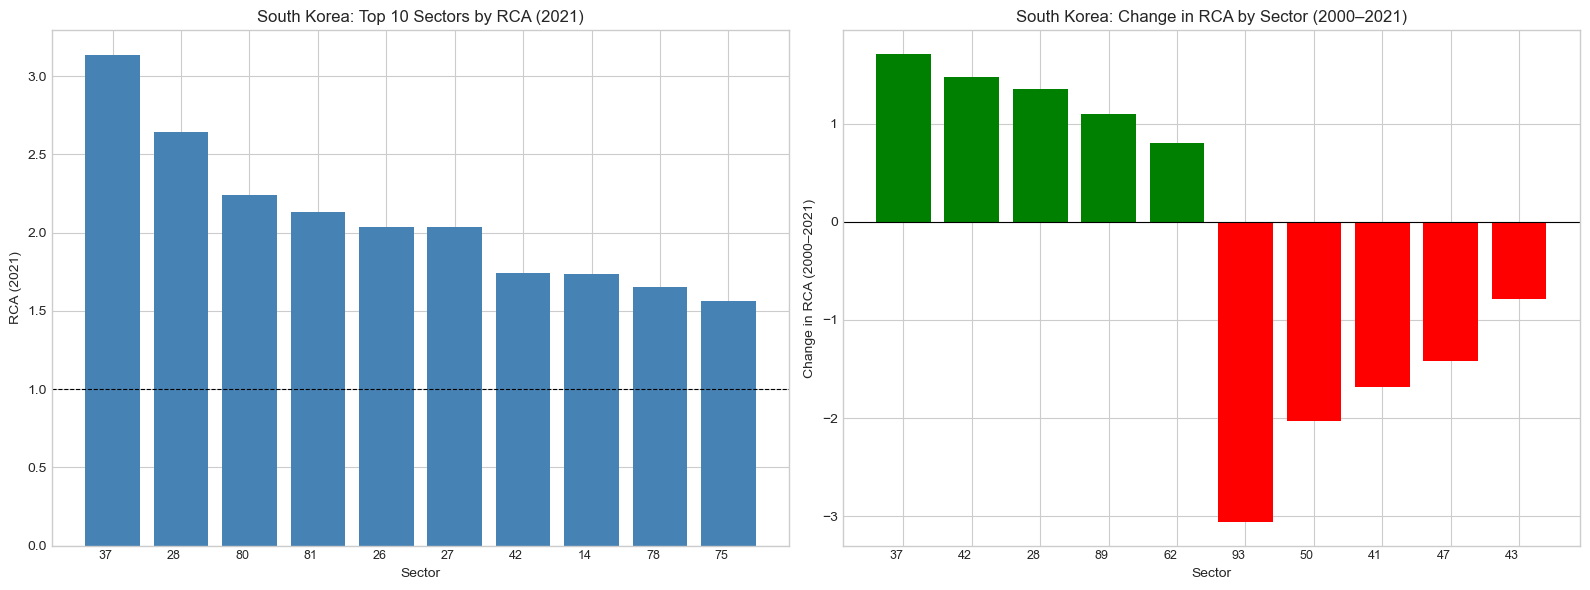

In [8]:
# HS2 code to short sector name mapping (covering all sectors appearing in Korea's top/change charts)
hs2_names = {
    14: "Veg. Plaiting", 26: "Ores & Minerals", 27: "Fuels",
    28: "Inorg. Chemicals", 29: "Org. Chemicals", 37: "Photo/Optical",
    38: "Misc. Chemicals", 39: "Plastics", 40: "Rubber",
    41: "Raw Hides", 42: "Leather Goods", 43: "Furskins",
    47: "Wood Pulp", 50: "Silk", 62: "Apparel (woven)",
    72: "Iron & Steel", 73: "Steel Articles", 75: "Nickel",
    78: "Lead", 80: "Tin", 81: "Spec. Metals",
    84: "Machinery", 85: "Electronics", 87: "Vehicles",
    89: "Ships & Boats", 90: "Precision Instr.", 93: "Arms & Ammo",
}

# Top 10 by RCA level in 2021; top 5 gainers and bottom 5 losers by change
top10 = rca.sort_values("rca_2021", ascending=False).head(10)
sel   = pd.concat([rca.sort_values("rca_change", ascending=False).head(5),
                   rca.sort_values("rca_change").head(5)]).drop_duplicates(subset="hs2")

# Map HS2 codes to readable names for both subsets
top10_labels = top10["hs2"].astype(str)
sel_labels   = sel["hs2"].astype(str)

# Color bars green/red based on direction of RCA change
sel_colors = ["green" if v > 0 else "red" for v in sel["rca_change"]]

plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: top 10 sectors by RCA level
ax1.bar(range(len(top10)), top10["rca_2021"], color="steelblue")
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels(top10_labels, rotation=0, ha="right", fontsize=9)
ax1.axhline(1, color="black", linewidth=0.8, linestyle="--")            # RCA = 1 threshold
ax1.set_xlabel("Sector")
ax1.set_ylabel("RCA (2021)")
ax1.set_title("South Korea: Top 10 Sectors by RCA (2021)")

# Right panel: biggest gainers and losers, colored by direction
ax2.bar(range(len(sel)), sel["rca_change"], color=sel_colors)
ax2.set_xticks(range(len(sel)))
ax2.set_xticklabels(sel_labels, rotation=0, ha="right", fontsize=9)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Sector")
ax2.set_ylabel("Change in RCA (2000–2021)")
ax2.set_title("South Korea: Change in RCA by Sector (2000–2021)")

plt.tight_layout()
plt.show()



South Korea's export structure reveals a paradox: its world-famous industries do not reflect its deepest comparative advantages. In 2021, Korea's strongest specialization lies in Photographic/Cinematographic Goods (HS 37) and Inorganic Chemicals (HS 28), with RCA indices above 2.5, suggesting Korea's competitive edge is concentrated in specialized materials manufacturing and industrial chemistry. This matters for policy: globally contested sectors may offer lower marginal returns to additional government support than niche sectors where Korea already punches above its weight.

Between 2000 and 2021, Korea's comparative advantage shifted decisively away from labor-intensive and legacy industries. The largest RCA declines occurred in Arms & Ammunition (HS 93), Silk (HS 50), and Raw Hides (HS 41), consistent with cost-driven offshoring or deliberate industrial de-emphasis. Meanwhile, Korea deepened its advantage in Photographic/Cinematographic Goods (HS 37), Ships & Boats (HS 89), and Inorganic Chemicals (HS 28), reflecting a successful but incomplete industrial upgrade toward knowledge-intensive manufacturing. Policy funds should reinforce this trajectory — targeting specialty materials and chemicals ecosystems — rather than subsidizing mature sectors where comparative advantage is eroding.

## Problem 4b: Imagining Global Trade without the WTO

In [9]:
# Load gravity data and filter to South Korea as exporter, latest year (2020)
gravity = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-gravity.csv")

In [10]:
# Filter to KOR exports, year 2020
grav_kor = gravity[(gravity["iso_o"] == "KOR") & (gravity["year"] == 2020)].copy()


In [11]:
# Construct variables
grav_kor["lvalue"]   = np.log(1 + grav_kor["value"])          # log(1+trade) to retain zeros
grav_kor["ldist"]    = np.log(grav_kor["distw"])
grav_kor["lgdp_d"]   = np.log(grav_kor["gdp_d"])

# Drop rows missing any regressor
grav_kor_clean = grav_kor.dropna(subset=["lvalue","ldist","lgdp_d","contig",
                                          "comlang_ethno","comleg_posttrans",
                                          "rta","wto_d"])


In [12]:
# OLS gravity regression
model = smf.ols(
    "lvalue ~ ldist + lgdp_d + comlang_ethno + comleg_posttrans + rta + wto_d",
    data=grav_kor_clean
).fit(cov_type="HC1")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 lvalue   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     109.7
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.32e-57
Time:                        17:30:34   Log-Likelihood:                -335.32
No. Observations:                 188   AIC:                             684.6
Df Residuals:                     181   BIC:                             707.3
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            8.1067      2.731  

In [13]:
# Counterfactual: WTO collapses — set wto_d = 0 for all partners
grav_kor_cf = grav_kor_clean.copy()
grav_kor_cf["wto_d"] = 0

# Predicted trade under actual and counterfactual
grav_kor_clean["yhat"]    = model.predict(grav_kor_clean)
grav_kor_clean["yhat_cf"] = model.predict(grav_kor_cf)

# Aggregate predicted change
total_actual = grav_kor_clean["yhat"].sum()
total_cf     = grav_kor_clean["yhat_cf"].sum()
pct_change   = (total_cf - total_actual) / total_actual * 100

print(f"Predicted log-exports (actual WTO):        {total_actual:.2f}")
print(f"Predicted log-exports (WTO collapsed):     {total_cf:.2f}")
print(f"Predicted % change in exports if WTO gone: {pct_change:.2f}%")
print(f"WTO_d coefficient: {model.params['wto_d']:.4f}")
print(f"Implied per-partner effect: {(np.exp(model.params['wto_d']) - 1)*100:.2f}%")

Predicted log-exports (actual WTO):        2149.12
Predicted log-exports (WTO collapsed):     2145.41
Predicted % change in exports if WTO gone: -0.17%
WTO_d coefficient: 0.0236
Implied per-partner effect: 2.39%


/var/folders/6q/74pzr8f57sg94hmlp5n87ybh0000gp/T/ipykernel_6184/4038259611.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grav_kor_clean["yhat"]    = model.predict(grav_kor_clean)
/var/folders/6q/74pzr8f57sg94hmlp5n87ybh0000gp/T/ipykernel_6184/4038259611.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grav_kor_clean["yhat_cf"] = model.predict(grav_kor_cf)


The gravity model explains 77% of the variation in South Korea's export flows in 2020, with distance and destination market size emerging as the dominant predictors. A 1% increase in distance is associated with roughly 1.5% lower exports, while a 1% increase in destination GDP is associated with approximately 0.96% higher exports — both significant at the 1% level. Having a Regional Trade Agreement in place is associated with approximately 68% higher exports (exp(0.515)−1), significant at the 5% level, suggesting that bilateral trade institutions meaningfully shape Korea's export capacity. By contrast, the WTO membership coefficient for destination partners is near zero (0.024) and statistically insignificant (p=0.960), implying that the model cannot detect a meaningful WTO effect on Korean exports. The counterfactual simulation — setting all destination WTO membership to zero — predicts only a −0.17% decline in total exports, a negligible effect. This is not because the WTO is irrelevant theoretically, but because nearly all of Korea's significant trading partners are already WTO members, leaving insufficient non-WTO variation in the data to identify the effect. In a world without the WTO, Korea's export exposure would likely be far greater than the model suggests.

## Problem 4c: Barriers to Trade

In a world without the WTO, the gravity model points to regional trade as Korea's most actionable lever for sustaining export growth. The Regional Trade Agreement (RTA) coefficient (0.515) is statistically significant and implies roughly 68% higher exports to partner countries — the largest policy-responsive effect in the model. Without the WTO's multilateral framework enforcing baseline tariff commitments, Korea should aggressively pursue and deepen bilateral and regional trade agreements, especially with countries where it currently lacks coverage. This is a direct substitute for the stability the WTO provided.

Beyond RTAs, the model highlights destination market size (lgdp_d, coef = 0.96) as the strongest predictor of exports, suggesting Korea should prioritize market access to high-growth economies, particularly in Southeast Asia and South Asia, where GDP growth over time would boost Korea's export potential over time. The insignificance of common language and common legal system in Korea's case underscores its already-diversified trading relationships, but in a more fragmented post-WTO order these frictions could grow. Therefore, Korea should invest in trade facilitation infrastructure — standardized contracts, dispute resolution mechanisms, and export financing — to reduce the effective cost of trading with partners who lack institutional alignment with Korea. Distance remains the most powerful barrier (coef = −1.51), and while geography cannot be changed, investments in logistics, shipping infrastructure, and digital trade platforms can reduce its effective impact on export costs.

## Problem 5: Summary Discussion

South Korea's analysis across four analytical frameworks points toward a coherent set of policy priorities. Development accounting reveals that Korea's growth has been overwhelmingly capital-driven, with TFP remaining flat since 1980 — meaning future productivity gains must come from structural transformation rather than continued factor accumulation. The RCA analysis reinforces this: Korea's deepest comparative advantages lie not in its headline industries but in specialized materials and chemicals sectors, while its legacy labor-intensive industries are in sustained decline. The gravity model confirms that RTAs are Korea's most effective policy instrument for sustaining export volume, and that distance remains the single largest structural barrier to trade.

To increase exports and improve productivity, Korea's Ministry of Commerce should target new budget funds toward three priorities. First, Korea should deepen its RTA network — particularly with high-growth Southeast and South Asian economies — to replicate the trade-boosting effects that the WTO's multilateral framework previously provided. Second, funds should be directed toward the precision materials and specialty chemicals ecosystems where Korea already holds a strong and growing comparative advantage, reinforcing rather than redirecting existing industrial strengths. Third, Korea should invest in logistics and digital trade infrastructure to reduce the effective cost of distance, which the gravity model identifies as the dominant structural barrier to export growth. Together these policies would address Korea's core challenge: transitioning from an input-driven growth model to one anchored in productivity, specialization, and institutional trade relationships.